In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_excel('/content/base_processada.xlsx')
df.head()


,Unnamed: 0,ano_pede,inde_2022,inde_2023,n_av,iaa,ieg,ips,ipp,ida,mat,por,ing,ipv,ian,fase_ideal,defasagem,risco_defasagem_atual
0,0,2024,NaN,NaN,3.0,10.002,8.666667,6.26,5.625,8.0,10.0,6.0,NaN,5.446667,10.0,0,0,0
1,1,2024,NaN,NaN,3.0,10.002,9.333333,3.76,7.500,8.0,10.0,6.0,NaN,7.050000,10.0,0,0,0
2,2,2024,NaN,NaN,3.0,10.002,9.083333,3.76,7.500,8.0,10.0,6.0,NaN,7.046667,10.0,0,0,0
3,3,2024,NaN,8.63895,3.0,8.002,9.750000,3.76,6.875,7.0,8.0,6.0,NaN,7.213333,5.0,1,-1,1
4,4,2024,NaN,NaN,3.0,9.002,4.166667,3.76,5.000,7.5,8.0,7.0,NaN,4.173333,5.0,1,-1,1


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3030 entries, 0 to 3029
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ano_pede               3030 non-null   int64  
 1   inde_2022              1932 non-null   float64
 2   inde_2023              1621 non-null   float64
 3   n_av                   2954 non-null   float64
 4   iaa                    2865 non-null   float64
 5   ieg                    2954 non-null   float64
 6   ips                    2859 non-null   float64
 7   ipp                    1992 non-null   float64
 8   ida                    2852 non-null   float64
 9   mat                    2846 non-null   float64
 10  por                    2845 non-null   float64
 11  ing                    1091 non-null   float64
 12  ipv                    2852 non-null   float64
 13  ian                    3030 non-null   float64
 14  fase_ideal             3030 non-null   int64  
 15  defa

,ano_pede,inde_2022,inde_2023,n_av,iaa,ieg,ips,ipp,ida,mat,por,ing,ipv,ian,fase_ideal,defasagem,risco_defasagem_atual
count,3030.00000,1932.000000,1621.000000,2954.000000,2865.000000,2954.000000,2859.000000,1992.000000,2852.000000,2846.000000,2845.000000,1091.000000,2852.000000,3030.000000,3030.000000,3030.000000,3030.000000
mean,2023.09769,7.187687,7.390479,3.031821,7.918225,7.945696,6.287129,7.555203,6.375964,6.161595,6.430668,6.289413,7.545476,7.179043,3.202310,-0.642904,0.556766
std,0.80995,0.954370,0.881769,1.063670,2.626209,2.152281,1.792491,0.938990,1.956637,2.398341,2.138916,2.732636,1.084347,2.535266,2.180452,0.866382,0.496849
min,2022.00000,3.031806,3.745542,0.000000,0.000000,0.000000,2.500000,2.500000,0.000000,0.000000,0.000000,0.000000,2.500000,2.500000,0.000000,-5.000000,0.000000
25%,2022.00000,6.671442,6.784075,2.000000,7.900000,7.300000,5.020000,7.083333,5.100000,4.800000,5.200000,4.500000,6.984000,5.000000,2.000000,-1.000000,0.000000
50%,2023.00000,7.306000,7.454250,3.000000,8.751000,8.600000,7.500000,7.500000,6.666667,6.300000,6.700000,6.700000,7.583000,5.000000,3.000000,-1.000000,1.000000
75%,2024.00000,7.863000,8.015200,4.000000,9.500000,9.400000,7.510000,8.125000,7.833333,8.000000,8.000000,8.500000,8.255000,10.000000,4.000000,0.000000,1.000000
max,2024.00000,9.442000,9.371200,6.000000,10.002000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.010000,10.000000,8.000000,3.000000,1.000000


In [ ]:
df['risco_defasagem_atual'].value_counts()
df['defasagem'].value_counts()

,count
defasagem,
-1,1259
0,1152
-2,383
1,165
-3,39
2,24
-4,5
3,2
-5,1


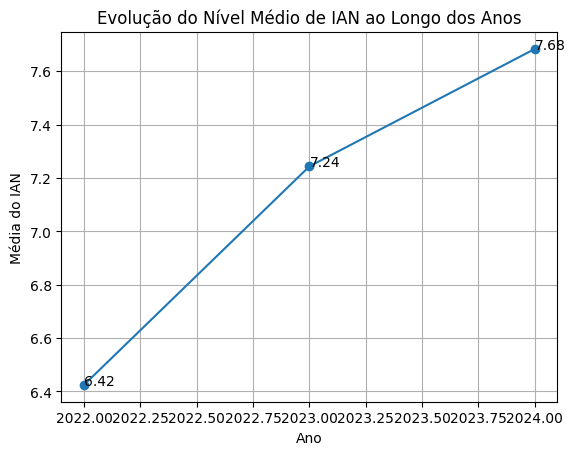

In [ ]:
#01 Adequação do nível (IAN): Qual é o perfil geral de defasagem dos alunos (IAN) e como ele evolui ao longo do ano?

# Estatística geral
df['ian'].describe()

# Média por ano
df.groupby('ano_pede')['ian'].mean()

# Distribuição por ano
df.groupby(['ano_pede','ian']).size().unstack()

# calcular média do IAN por ano
media_ian = df.groupby('ano_pede')['ian'].mean()

# criar gráfico
plt.figure()
plt.plot(media_ian.index, media_ian.values, marker='o')

# personalização
plt.title('Evolução do Nível Médio de IAN ao Longo dos Anos')
plt.xlabel('Ano')
plt.ylabel('Média do IAN')
plt.grid()

# mostrar valores nos pontos
for x, y in zip(media_ian.index, media_ian.values):
    plt.text(x, y, round(y, 2))

plt.show()

fase_ideal
0    7.450424
1    7.289378
2    6.711298
3    5.900259
4    5.589668
5    5.697652
6    5.745833
7    5.979720
8    5.744444
Name: ida, dtype: float64


<Figure size 640x480 with 0 Axes>

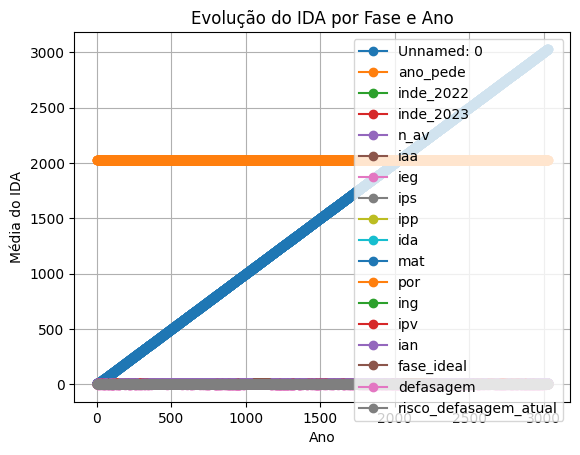

In [ ]:
#02 Desempenho acadêmico (IDA): O desempenho acadêmico médio (IDA) está melhorando, estagnado ou caindo ao longo das fases e anos?

# Média do IDA por fase (tratando como categoria)
media_ida_fase = df.groupby('fase_ideal')['ida'].mean()
print(media_ida_fase)

# Cruzamento fase + ano
df.groupby(['ano_pede','fase_ideal'])['ida'].mean().unstack()

# criar gráfico

plt.figure()
df.plot(marker='o')

plt.title('Evolução do IDA por Fase e Ano')
plt.xlabel('Ano')
plt.ylabel('Média do IDA')
plt.grid()

plt.show()

Correlação entre IEG, IDA e IPV:
          ieg       ida       ipv
ieg  1.000000  0.539057  0.558200
ida  0.539057  1.000000  0.557072
ipv  0.558200  0.557072  1.000000

Média de IDA por faixa de IEG:
faixa_ieg
Baixo          4.792236
Médio-Baixo    6.209474
Médio-Alto     6.906356
Alto           7.461095
Name: ida, dtype: float64

IEG médio por risco de defasagem:
risco_defasagem_atual
0    7.776492
1    8.073126
Name: ieg, dtype: float64


/tmp/ipython-input-461/1666644892.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  media_por_faixa = df.groupby('faixa_ieg')['ida'].mean()


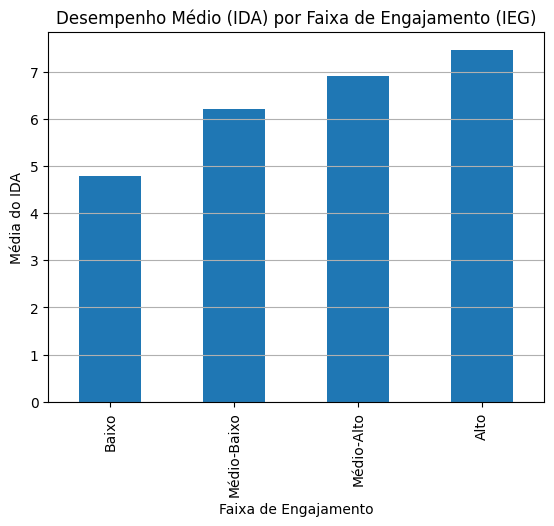

In [ ]:
#03 Engajamento nas atividades (IEG): O grau de engajamento dos alunos (IEG) tem relação direta com seus indicadores de desempenho (IDA) e do ponto de virada (IPV)?


# Matriz de correlação entre as três variáveis
# Correlação mede força e direção da relação linear (-1 a +1)
corr_ieg = df[['ieg','ida','ipv']].corr()
print("Correlação entre IEG, IDA e IPV:")
print(corr_ieg)


# Média de IDA por nível de engajamento (dividindo em quartis)
# Isso ajuda a ver se alunos mais engajados têm melhor desempenho
df['faixa_ieg'] = pd.qcut(df['ieg'], 4, labels=['Baixo','Médio-Baixo','Médio-Alto','Alto'])

media_por_faixa = df.groupby('faixa_ieg')['ida'].mean()
print("\nMédia de IDA por faixa de IEG:")
print(media_por_faixa)


# Engajamento médio de alunos com e sem risco
# Verifica se baixo engajamento está associado ao risco de defasagem
media_risco = df.groupby('risco_defasagem_atual')['ieg'].mean()
print("\nIEG médio por risco de defasagem:")
print(media_risco)

# criar gráfico

plt.figure()
media_por_faixa.plot(kind='bar')

plt.title('Desempenho Médio (IDA) por Faixa de Engajamento (IEG)')
plt.xlabel('Faixa de Engajamento')
plt.ylabel('Média do IDA')
plt.grid(axis='y')

plt.show()

===== Correlação entre IAA, IDA e IEG =====
          iaa       ida       ieg
iaa  1.000000  0.115241  0.133078
ida  0.115241  1.000000  0.539057
ieg  0.133078  0.539057  1.000000

===== Média de IDA por Faixa de IAA =====
faixa_iaa
Baixa          5.971827
Médio-Baixa    6.325723
Médio-Alta     6.583413
Alta           6.679007
Name: ida, dtype: float64

===== Média de IEG por Faixa de IAA =====
faixa_iaa
Baixa          7.836760
Médio-Baixa    8.223035
Médio-Alta     8.404529
Alta           8.515979
Name: ieg, dtype: float64


/tmp/ipython-input-461/1640941179.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  media_ida_iaa = df.groupby('faixa_iaa')['ida'].mean()
/tmp/ipython-input-461/1640941179.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  media_ieg_iaa = df.groupby('faixa_iaa')['ieg'].mean()


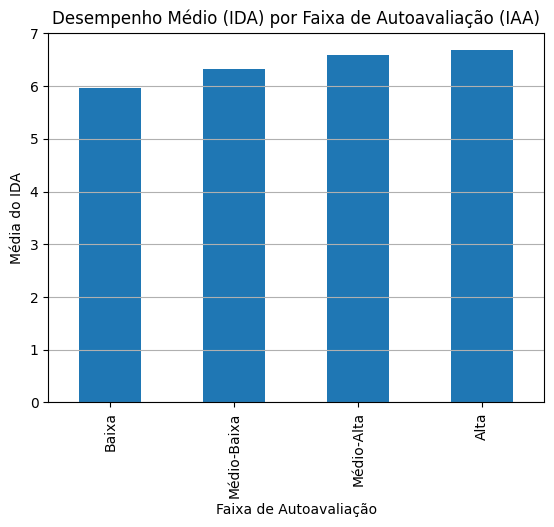

In [ ]:
#04 Autoavaliação (IAA): As percepções dos alunos sobre si mesmos (IAA) são coerentes com seu desempenho real (IDA) e engajamento (IEG)?

#  Correlação entre IAA, IDA e IEG
corr_iaa = df[['iaa','ida','ieg']].corr()
print("===== Correlação entre IAA, IDA e IEG =====")
print(corr_iaa)

#  Comparação prática – IDA por faixa de IAA
df['faixa_iaa'] = pd.qcut(df['iaa'], 4,
                          labels=['Baixa','Médio-Baixa','Médio-Alta','Alta'])

media_ida_iaa = df.groupby('faixa_iaa')['ida'].mean()
print("\n===== Média de IDA por Faixa de IAA =====")
print(media_ida_iaa)

#  Comparação prática – IEG por faixa de IAA
media_ieg_iaa = df.groupby('faixa_iaa')['ieg'].mean()
print("\n===== Média de IEG por Faixa de IAA =====")
print(media_ieg_iaa)

# criar gráfico

plt.figure()
media_ida_iaa.plot(kind='bar')

plt.title('Desempenho Médio (IDA) por Faixa de Autoavaliação (IAA)')
plt.xlabel('Faixa de Autoavaliação')
plt.ylabel('Média do IDA')
plt.grid(axis='y')

plt.show()


===== Correlação do IPS com IDA, IEG e IPV =====
          ips       ida       ieg       ipv
ips  1.000000  0.022485 -0.046264 -0.048750
ida  0.022485  1.000000  0.539057  0.557072
ieg -0.046264  0.539057  1.000000  0.558200
ipv -0.048750  0.557072  0.558200  1.000000

===== Média de IDA por Faixa de IPS =====
faixa_ips
Baixo          6.267817
Médio-Baixo    6.292864
Médio-Alto     6.474270
Alto           6.279583
Name: ida, dtype: float64

===== Média de IEG por Faixa de IPS =====
faixa_ips
Baixo          8.321863
Médio-Baixo    8.160437
Médio-Alto     8.214204
Alto           8.262370
Name: ieg, dtype: float64

===== IPS Médio por Risco de Defasagem =====
risco_defasagem_atual
0    6.286179
1    6.287794
Name: ips, dtype: float64


/tmp/ipython-input-461/1779231924.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  media_ida_ips = df.groupby('faixa_ips')['ida'].mean()
/tmp/ipython-input-461/1779231924.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  media_ieg_ips = df.groupby('faixa_ips')['ieg'].mean()


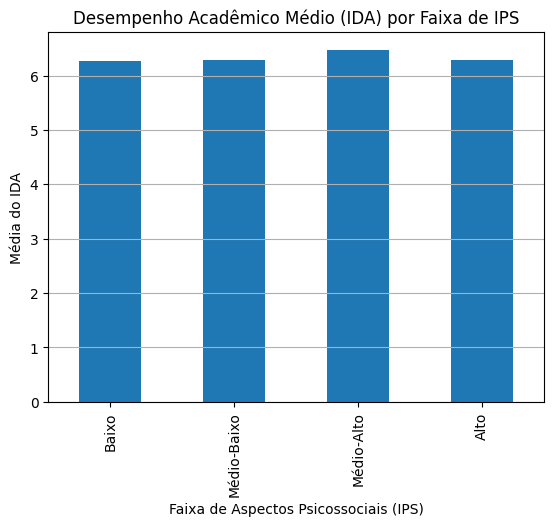

In [ ]:
#05 Aspectos psicossociais (IPS): Há padrões psicossociais (IPS) que antecedem quedas de desempenho acadêmico ou de engajamento?

#  Correlação entre IPS e indicadores principais
cor_ips = df[['ips','ida','ieg','ipv']].corr()

print("\n===== Correlação do IPS com IDA, IEG e IPV =====")
print(cor_ips)


#  Média de IDA por faixa de IPS
df['faixa_ips'] = pd.cut(df['ips'],
                         bins=[0,5,7,8.5,10],
                         labels=['Baixo','Médio-Baixo','Médio-Alto','Alto'])

media_ida_ips = df.groupby('faixa_ips')['ida'].mean()
media_ieg_ips = df.groupby('faixa_ips')['ieg'].mean()

print("\n===== Média de IDA por Faixa de IPS =====")
print(media_ida_ips)

print("\n===== Média de IEG por Faixa de IPS =====")
print(media_ieg_ips)


#  IPS médio por risco de defasagem
ips_risco = df.groupby('risco_defasagem_atual')['ips'].mean()

print("\n===== IPS Médio por Risco de Defasagem =====")
print(ips_risco)

# criar gráfico

plt.figure()
media_ida_ips.plot(kind='bar')

plt.title('Desempenho Acadêmico Médio (IDA) por Faixa de IPS')
plt.xlabel('Faixa de Aspectos Psicossociais (IPS)')
plt.ylabel('Média do IDA')
plt.grid(axis='y')

plt.show()


===== Correlação entre IPP e IAN =====
          ipp       ian
ipp  1.000000  0.123398
ian  0.123398  1.000000

===== Média de IPP por Nível de IAN =====
ian
2.5     7.010417
5.0     7.459217
10.0    7.678196
Name: ipp, dtype: float64

===== Média de IPP por Defasagem =====
defasagem
-5         NaN
-4    4.218750
-3    7.184896
-2    7.113731
-1    7.548953
 0    7.635912
 1    7.975507
 2    7.637868
 3    7.968750
Name: ipp, dtype: float64

===== IPP Médio por Risco de Defasagem =====
risco_defasagem_atual
0    7.678196
1    7.452178
Name: ipp, dtype: float64


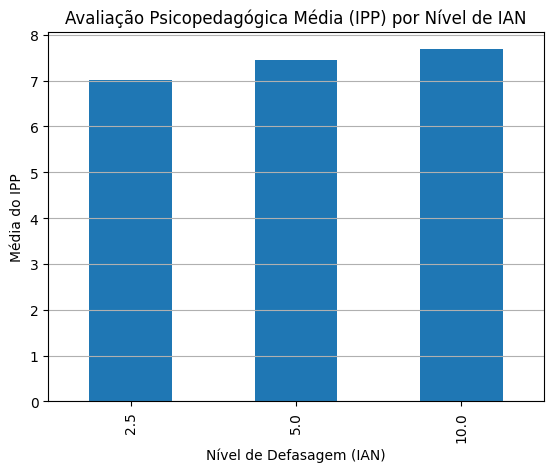

In [ ]:
#06 Aspectos psicopedagógicos (IPP): As avaliações psicopedagógicas (IPP) confirmam ou contradizem a defasagem identificada pelo IAN?

#  Correlação entre IPP e IAN
# (esperado: correlação positiva → maior IPP associado a maior IAN)

cor_ipp_ian = df[['ipp','ian']].corr()

print("\n===== Correlação entre IPP e IAN =====")
print(cor_ipp_ian)


#  Média de IPP por nível de IAN
# (verificar se alunos com IAN 2.5, 5 e 10 têm IPP diferente)

media_ipp_ian = df.groupby('ian')['ipp'].mean()

print("\n===== Média de IPP por Nível de IAN =====")
print(media_ipp_ian)


#  IPP médio por defasagem estrutural
# (avaliar se maior defasagem está associada a menor IPP)

media_ipp_defasagem = df.groupby('defasagem')['ipp'].mean()

print("\n===== Média de IPP por Defasagem =====")
print(media_ipp_defasagem)


#  IPP médio por risco de defasagem
# (comparar alunos em risco vs sem risco)

ipp_risco = df.groupby('risco_defasagem_atual')['ipp'].mean()

print("\n===== IPP Médio por Risco de Defasagem =====")
print(ipp_risco)

# criar gráfico

plt.figure()
media_ipp_ian.plot(kind='bar')

plt.title('Avaliação Psicopedagógica Média (IPP) por Nível de IAN')
plt.xlabel('Nível de Defasagem (IAN)')
plt.ylabel('Média do IPP')
plt.grid(axis='y')

plt.show()


===== Correlação do IPV com outros indicadores =====
          ipv       ida       ieg       iaa       ips       ipp
ipv  1.000000  0.557072  0.558200  0.062728 -0.048750  0.606649
ida  0.557072  1.000000  0.539057  0.115241  0.022485  0.369218
ieg  0.558200  0.539057  1.000000  0.133078 -0.046264  0.328542
iaa  0.062728  0.115241  0.133078  1.000000  0.157373  0.054461
ips -0.048750  0.022485 -0.046264  0.157373  1.000000  0.064209
ipp  0.606649  0.369218  0.328542  0.054461  0.064209  1.000000

===== Indicadores mais relacionados ao IPV =====
ipv    1.000000
ipp    0.606649
ieg    0.558200
ida    0.557072
iaa    0.062728
ips   -0.048750
Name: ipv, dtype: float64

===== Média de IPV por Faixa de IDA =====
faixa_ida
Baixo          6.657243
Médio-Baixo    7.500776
Médio-Alto     8.021715
Alto           8.353826
Name: ipv, dtype: float64

===== Média de IPV por Faixa de IEG =====
faixa_ieg
Baixo          5.893377
Médio-Baixo    6.736772
Médio-Alto     7.360606
Alto           8.002544
Na

/tmp/ipython-input-461/2329525733.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ipv_por_ida = df.groupby('faixa_ida')['ipv'].mean()
/tmp/ipython-input-461/2329525733.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ipv_por_ieg = df.groupby('faixa_ieg')['ipv'].mean()


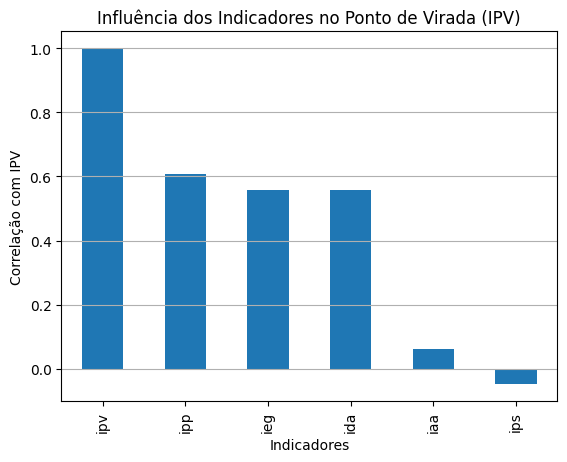

In [ ]:
#07 Ponto de virada (IPV): Quais comportamentos - acadêmicos, emocionais ou de engajamento - mais influenciam o IPV ao longo do tempo?


#  Correlação do IPV com os principais indicadores
cor_ipv = df[['ipv','ida','ieg','iaa','ips','ipp']].corr()

print("\n===== Correlação do IPV com outros indicadores =====")
print(cor_ipv)


#  Correlação ordenada (maior influência primeiro)
cor_ipv_ordenado = cor_ipv['ipv'].sort_values(ascending=False)

print("\n===== Indicadores mais relacionados ao IPV =====")
print(cor_ipv_ordenado)


#  Média de IPV por faixa de IDA (desempenho acadêmico)
df['faixa_ida'] = pd.cut(df['ida'],
                         bins=[0,5,7,8.5,10],
                         labels=['Baixo','Médio-Baixo','Médio-Alto','Alto'])

ipv_por_ida = df.groupby('faixa_ida')['ipv'].mean()

print("\n===== Média de IPV por Faixa de IDA =====")
print(ipv_por_ida)


#  Média de IPV por faixa de IEG (engajamento)
df['faixa_ieg'] = pd.cut(df['ieg'],
                         bins=[0,5,7,8.5,10],
                         labels=['Baixo','Médio-Baixo','Médio-Alto','Alto'])

ipv_por_ieg = df.groupby('faixa_ieg')['ipv'].mean()

print("\n===== Média de IPV por Faixa de IEG =====")
print(ipv_por_ieg)

# criar gráfico

plt.figure()
cor_ipv_ordenado.plot(kind='bar')

plt.title('Influência dos Indicadores no Ponto de Virada (IPV)')
plt.xlabel('Indicadores')
plt.ylabel('Correlação com IPV')
plt.grid(axis='y')

plt.show()

===== Correlação INDE x Indicadores =====
           inde_2023       ida       ieg       ips       ipp
inde_2023   1.000000  0.591087  0.452409  0.260423  0.459603
ida         0.591087  1.000000  0.539057  0.022485  0.369218
ieg         0.452409  0.539057  1.000000 -0.046264  0.328542
ips         0.260423  0.022485 -0.046264  1.000000  0.064209
ipp         0.459603  0.369218  0.328542  0.064209  1.000000

===== Top 10 Combinações que Elevam INDE =====
combo
Alto_Alto_Alto_Alto      8.286330
Alto_Alto_Baixo_Alto     7.915618
Alto_Alto_Alto_Baixo     7.897510
Baixo_Alto_Alto_Alto     7.689694
Alto_Baixo_Alto_Alto     7.688855
Alto_Alto_Baixo_Baixo    7.453398
Alto_Baixo_Alto_Baixo    7.423535
Baixo_Alto_Alto_Baixo    7.411287
Baixo_Alto_Baixo_Alto    7.268974
Baixo_Baixo_Alto_Alto    7.206188
Name: inde_2023, dtype: float64


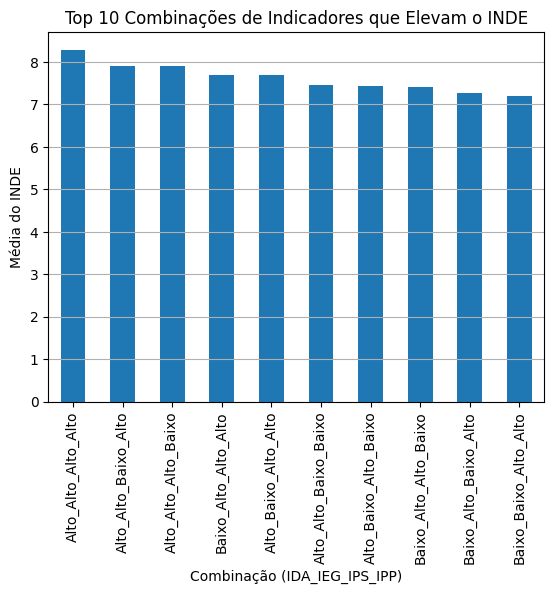

In [ ]:
#08 Multidimensionalidade dos indicadores: Quais combinações de indicadores (IDA + IEG + IPS + IPP) elevam mais a nota global do aluno (INDE)?

#  Correlação INDE x indicadores principais
cor_inde = df[['inde_2023','ida','ieg','ips','ipp']].corr()
print("===== Correlação INDE x Indicadores =====")
print(cor_inde)

#  Criar níveis Alto/Baixo usando mediana
for col in ['ida','ieg','ips','ipp']:
    df[f'{col}_nivel'] = df[col].apply(lambda x: 'Alto' if x >= df[col].median() else 'Baixo')

#  Combinar os 4 indicadores
df['combo'] = df['ida_nivel'] + "_" + df['ieg_nivel'] + "_" + df['ips_nivel'] + "_" + df['ipp_nivel']

#  Média do INDE por combinação
media_combo = df.groupby('combo')['inde_2023'].mean().sort_values(ascending=False)
print("\n===== Top 10 Combinações que Elevam INDE =====")
print(media_combo.head(10))

# criar gráfico

plt.figure()
media_combo.head(10).plot(kind='bar')

plt.title('Top 10 Combinações de Indicadores que Elevam o INDE')
plt.xlabel('Combinação (IDA_IEG_IPS_IPP)')
plt.ylabel('Média do INDE')
plt.grid(axis='y')

plt.show()



===== Avaliação do Modelo =====
              precision    recall  f1-score   support

           0       0.65      0.60      0.62       622
           1       0.57      0.62      0.60       534

    accuracy                           0.61      1156
   macro avg       0.61      0.61      0.61      1156
weighted avg       0.61      0.61      0.61      1156

ROC AUC: 0.6449022724809422

===== Variáveis Mais Importantes para Prever Risco =====
inde_2022    0.229245
inde_2023    0.158201
ipv          0.151112
ida          0.142858
ieg          0.108091
iaa          0.079749
ips          0.071877
ipp          0.058867
dtype: float64


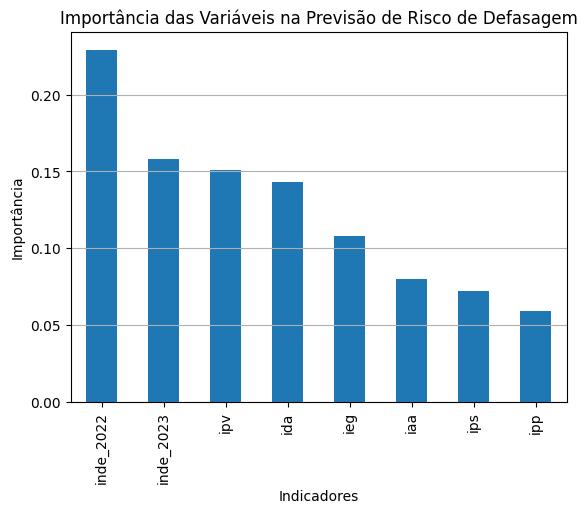

In [ ]:
#09 Previsão de risco com Machine Learning: Quais padrões nos indicadores permitem identificar alunos em risco antes de queda no desempenho
#ou aumento da defasagem? Construa um modelo preditivo que mostre uma
#probabilidade do aluno ou aluna entrar em risco de defasagem.

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import numpy as np

#  Criar target de risco (exemplo: IAN <= 5)
df['risco_ml'] = np.where(df['ian'] <= 5, 1, 0)

#  Selecionar variáveis preditoras (sem usar IAN para evitar vazamento)
features = ['ida','ieg','iaa','ips','ipp','ipv','inde_2022','inde_2023']
features = [f for f in features if f in df.columns]

X = df[features]
y = df['risco_ml']

#  Separar treino e teste (temporal se houver ano)
if 'ano_pede' in df.columns:
    X_train = X[df['ano_pede'] < 2024]
    y_train = y[df['ano_pede'] < 2024]
    X_test  = X[df['ano_pede'] == 2024]
    y_test  = y[df['ano_pede'] == 2024]
else:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )

#  Pipeline simples
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(n_estimators=300, random_state=42))
])

#  Treinar modelo
pipeline.fit(X_train, y_train)

#  Avaliar
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:,1]

print("\n===== Avaliação do Modelo =====")
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))

#  Importância das variáveis
importancias = pipeline.named_steps['model'].feature_importances_
ranking = pd.Series(importancias, index=features).sort_values(ascending=False)

print("\n===== Variáveis Mais Importantes para Prever Risco =====")
print(ranking)

# criar gráfico

plt.figure()
ranking.plot(kind='bar')

plt.title('Importância das Variáveis na Previsão de Risco de Defasagem')
plt.xlabel('Indicadores')
plt.ylabel('Importância')
plt.grid(axis='y')

plt.show()


===== Evolução Média por Ano =====
           ida   ieg   ips   ipp   ipv   ian
ano_pede                                    
2022      6.09  7.89  6.90   NaN  7.25  6.42
2023      6.66  8.70  5.12  7.56  8.03  7.24
2024      6.35  7.37  6.83  7.55  7.35  7.68

===== Média dos Indicadores por Fase =====
             ida   ieg   ips   ipp   ipv    ian
fase_ideal                                     
0           7.45  8.68  6.40  7.02  7.88  10.00
1           7.29  8.74  6.47  7.42  7.80   6.63
2           6.71  8.51  6.48  7.77  7.72   6.81
3           5.90  8.03  6.12  7.59  7.34   7.31
4           5.59  7.89  5.94  7.59  7.30   6.99
5           5.70  7.83  6.16  7.53  7.38   6.56
6           5.75  7.68  6.17  7.56  7.31   5.79
7           5.98  7.54  6.43  7.60  7.41   5.87
8           5.74  2.05  5.95  7.20  7.22   8.98

===== Média inde_2022 por Ano =====
ano_pede
2022    7.04
2023    7.26
2024    7.37
Name: inde_2022, dtype: float64

===== Média inde_2023 por Ano =====
ano_pede
2022

<Figure size 1200x600 with 0 Axes>

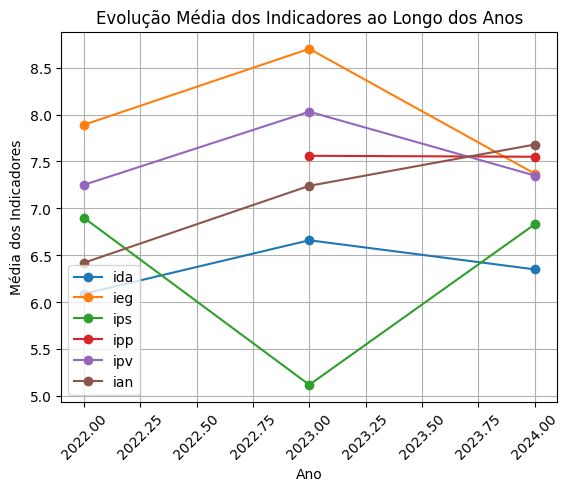

In [ ]:
#10 Efetividade do programa: Os indicadores mostram melhora consistente ao longo do ciclo nas diferentes fases (Quartzo, Ágata, Ametista e Topázio), confirmando o impacto real do programa?

# Evolução média dos indicadores por ano
indicadores = ['ida','ieg','ips','ipp','ipv','ian']

evolucao_ano = df.groupby('ano_pede')[indicadores].mean().round(2)

print("\n===== Evolução Média por Ano =====")
print(evolucao_ano)


#  Evolução média por fase
evolucao_fase = df.groupby('fase_ideal')[indicadores].mean().round(2)

print("\n===== Média dos Indicadores por Fase =====")
print(evolucao_fase)


#  INDE médio por ano (usando a coluna correta)
colunas_inde = [col for col in df.columns if 'inde' in col.lower()]

for col in colunas_inde:
    print(f"\n===== Média {col} por Ano =====")
    print(df.groupby('ano_pede')[col].mean().round(2))

# criar gráfico

plt.figure(figsize=(12,6))
evolucao_ano.plot(marker='o')

plt.title('Evolução Média dos Indicadores ao Longo dos Anos')
plt.xlabel('Ano')
plt.ylabel('Média dos Indicadores')

plt.xticks(rotation=45)  # rotaciona os anos

plt.grid()
plt.show()

===== Estatísticas do Score de Proteção =====
count    1985.000000
mean        7.239367
std         1.062141
min         2.323285
25%         6.594167
50%         7.372000
75%         8.023625
max         9.442726
Name: score_protecao, dtype: float64

===== Estatísticas do Score de Risco =====
count    1985.000000
mean        2.203359
std         1.062141
min         0.000000
25%         1.419101
50%         2.070726
75%         2.848560
max         7.119442
Name: score_risco, dtype: float64

===== Distribuição por Prioridade =====
nivel_prioridade
Muito Alta Prioridade    497
Alta Prioridade          496
Média Prioridade         496
Baixa Prioridade         496
Name: count, dtype: int64

===== Perfil Médio - Muito Alta Prioridade =====
ida    8.46
ieg    9.40
ips    6.97
ipp    8.16
ipv    8.53
ian    7.79
dtype: float64

===== Alunos com Perfil Crítico Multidimensional =====
perfil_critico
0    2970
1      60
Name: count, dtype: int64

Percentual de alunos críticos:
1.98 %


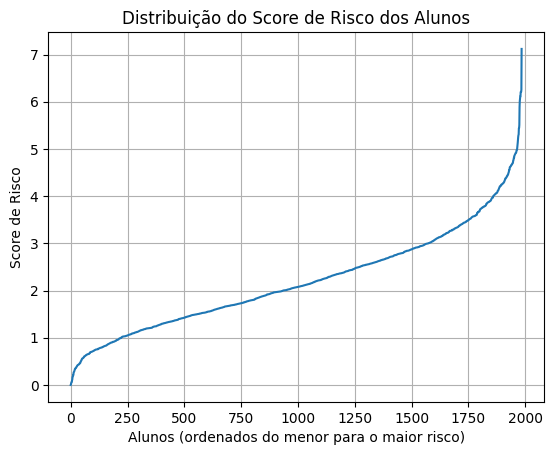

In [ ]:
#11  Insights e criatividade: Você pode adicionar mais insights e pontos de vista não abordados nas perguntas, utilize a criatividade e a análise dos dados
#para trazer sugestões para a Passos Mágicos.


# Score de PROTEÇÃO (quanto maior, melhor)

df['score_protecao'] = (
    df['ida'] * 0.30 +
    df['ieg'] * 0.25 +
    df['ips'] * 0.15 +
    df['ipp'] * 0.10 +
    df['ipv'] * 0.20
)

print("===== Estatísticas do Score de Proteção =====")
print(df['score_protecao'].describe())



# Transformar em Score de RISCO (invertido)


df['score_risco'] = df['score_protecao'].max() - df['score_protecao']

print("\n===== Estatísticas do Score de Risco =====")
print(df['score_risco'].describe())



# Classificação por prioridade


df['nivel_prioridade'] = pd.qcut(
    df['score_risco'],
    q=4,
    labels=[
        'Muito Alta Prioridade',
        'Alta Prioridade',
        'Média Prioridade',
        'Baixa Prioridade'
    ]
)

print("\n===== Distribuição por Prioridade =====")
print(df['nivel_prioridade'].value_counts())



#  Perfil Médio dos alunos mais críticos


print("\n===== Perfil Médio - Muito Alta Prioridade =====")
print(
    df[df['nivel_prioridade'] == 'Muito Alta Prioridade']
    [['ida','ieg','ips','ipp','ipv','ian']]
    .mean()
    .round(2)
)



#  Insight Avançado – Perfil Crítico Multidimensional

df['perfil_critico'] = np.where(
    (df['ida'] < 6) &
    (df['ieg'] < 6) &
    (df['ips'] < 6),
    1,
    0
)

print("\n===== Alunos com Perfil Crítico Multidimensional =====")
print(df['perfil_critico'].value_counts())

print("\nPercentual de alunos críticos:")
print(round(df['perfil_critico'].mean() * 100, 2), "%")

# criar gráfico

plt.figure()

df['score_risco'].sort_values().reset_index(drop=True).plot()

plt.title('Distribuição do Score de Risco dos Alunos')
plt.xlabel('Alunos (ordenados do menor para o maior risco)')
plt.ylabel('Score de Risco')
plt.grid()

plt.show()